# FD-CNN Fall Detection — Demo Notebook (Repeated Accelerometer Second Half)

This notebook demonstrates the pre-trained **AFD-CNN** model for fall detection from wrist-worn sensor windows.

**Concept:** 1200 raw sensor values (200 timesteps × 3 axes × 2 sensor halves) are treated as a 20×20 RGB image and classified by a 2-layer CNN into 8 activity classes.  
The **top half** of the image (rows 0–9) encodes the **accelerometer**, while the **bottom half** (rows 10–19) is rewritten in this notebook variant before visualisation and inference.

**Variant note:** This variant rewrites the lower 600 values before plotting and inference by copying the accelerometer half into the second half of the 1200-value input.

| Class label | Activity | Role in this notebook |
|---|---|---|
| 0 | **Fall** | Positive control |
| 2 | Walk | Negative control |
| 3 | Jog | Negative control |
| 4 | Jump | Negative control |
| 5 | Up-stairs | Negative control |
| 6 | Down-stairs | Negative control |
| 7 | Stand→Sit | Negative control |
| 9 | Sit→Stand | Negative control |

Reported accuracy on the test set: **97.87%**, fall sensitivity **100%**.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')   # so we can import cnn.py / dataset.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# TF1-compat mode (the model uses tf.compat.v1 placeholders & sessions)
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)

I0000 00:00:1776451067.958985   43848 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow version: 2.21.0
NumPy version: 2.4.4
Pandas version: 3.0.2


## 2. Load the Dataset Files

Each CSV row is one motion window: `label` + 1200 sensor values.

In [2]:
DATA_DIR = 'data/dataset'

# Class definitions — must match CLASS_LIST in cnn.py
CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NAMES = {0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
               5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand→Sit', 9: 'Sit→Stand'}

files = {
    0: '0_fall_data.csv',
    2: '2_walk_data.csv',
    3: '3_jog_data.csv',
    4: '4_jump_data.csv',
    5: '5_upstair_data.csv',
    6: '6_downstair_data.csv',
    7: '7_stand2sit_data.csv',
    9: '9_sit2stand_data.csv',
}

dfs = {label: pd.read_csv(os.path.join(DATA_DIR, fname), index_col=False)
       for label, fname in files.items()}

for label, df in dfs.items():
    print(f'  label={label:2d}  {CLASS_NAMES[label]:12s}  {len(df):5d} samples  '
          f'  sensor range [{df.iloc[:,1:].min().min():.0f}, {df.iloc[:,1:].max().max():.0f}]')

DEMO_VARIANT = 'repeat_acc'
SECOND_HALF_LABEL = 'repeated accelerometer proxy'
SECOND_HALF_SHORT = 'repeated acc'
FD_HALF_FILL = np.float32(255.0 / 2.0)

def rewrite_second_half(row_values):
    """Rewrite the lower 600 values of a sample according to the selected demo variant."""
    row_values = np.array(row_values, dtype=np.float32).reshape(-1)
    acc = row_values[:600].copy()
    if DEMO_VARIANT == "repeat_acc":
        second_half = acc.copy()
    else:
        second_half = np.full(acc.shape, FD_HALF_FILL, dtype=np.float32)
    return np.concatenate([acc, second_half]).astype(np.float32)

def rewrite_matrix_second_half(samples):
    """Vectorized rewrite of the lower 600 values for an (N, 1200) sample matrix."""
    samples = np.array(samples, dtype=np.float32)
    if samples.ndim == 1:
        return rewrite_second_half(samples)
    acc = samples[:, :600].copy()
    if DEMO_VARIANT == "repeat_acc":
        second_half = acc.copy()
    else:
        second_half = np.full(acc.shape, FD_HALF_FILL, dtype=np.float32)
    return np.concatenate([acc, second_half], axis=1).astype(np.float32)

print(f'Demo input layout: rows 0–9 = accelerometer, rows 10–19 = {SECOND_HALF_LABEL}')


  label= 0  Fall           1034 samples    sensor range [0, 250]
  label= 2  Walk           1060 samples    sensor range [0, 255]
  label= 3  Jog            1056 samples    sensor range [0, 250]
  label= 4  Jump           1044 samples    sensor range [0, 250]
  label= 5  Up-stairs      1071 samples    sensor range [0, 250]
  label= 6  Down-stairs    1071 samples    sensor range [0, 250]
  label= 7  Stand→Sit      1051 samples    sensor range [0, 250]
  label= 9  Sit→Stand      1048 samples    sensor range [0, 248]
Demo input layout: rows 0–9 = accelerometer, rows 10–19 = repeated accelerometer proxy


## 3. Visualise the Raw Sensor Signal

The original 1200 values encode **200 time-steps × 3 axes** for **two sensor halves** recorded at **100 Hz** (2 s window).  
- Values 1–600 → **accelerometer** (ax, ay, az for each of the 200 timesteps)  
- Values 601–1200 → **repeated accelerometer proxy** in this notebook variant  

Solid lines = accelerometer; dashed lines = rewritten second half used for this demo.


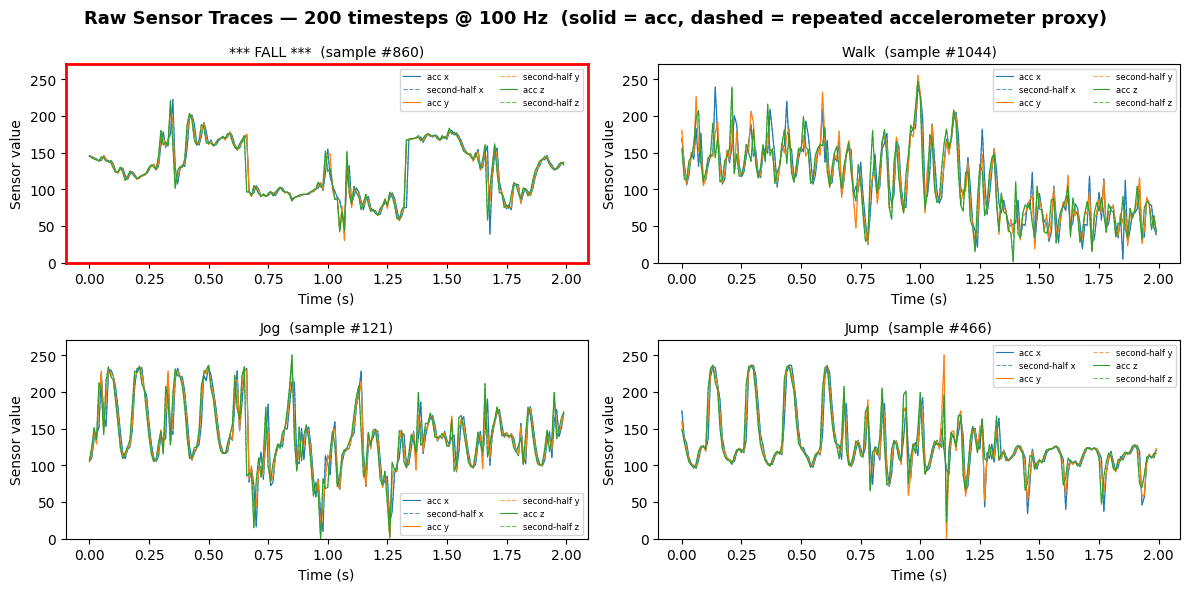

In [3]:
def plot_signals(row_values, title, ax):
    """Plot accelerometer (solid) and the rewritten second half (dashed) from a 1200-element sample @ 100 Hz."""
    row_values = rewrite_second_half(row_values)
    acc = row_values[:600].reshape(200, 3)
    second = row_values[600:].reshape(200, 3)
    t = np.arange(200) / 100.0
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for i, (name, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc[:, i], color=color, linewidth=0.8, linestyle='-', label=f'acc {name}')
        ax.plot(t, second[:, i], color=color, linewidth=0.8, linestyle='--', alpha=0.7,
                label=f'second-half {name}')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Sensor value')
    ax.legend(fontsize=6, ncol=2)
    ax.set_ylim(0, 270)

np.random.seed(42)
show_labels = [0, 2, 3, 4]   # Fall, Walk, Jog, Jump

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, label in zip(axes.flat, show_labels):
    sample_idx = np.random.randint(len(dfs[label]))
    values = dfs[label].iloc[sample_idx, 1:1201].values.astype(float)
    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    plot_signals(values, f'{tag}  (sample #{sample_idx})', ax)
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(f'Raw Sensor Traces — 200 timesteps @ 100 Hz  (solid = acc, dashed = {SECOND_HALF_LABEL})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Sensor Data as a 20×20 RGB "Image"

The FD-CNN model reshapes the 1200 values into a **20×20×3 pseudo-image** and normalises them to [−1, 1].  
The image encodes both halves spatially in this notebook variant:

| Image rows | Content | Values |
|---|---|---|
| 0–9 (top half) | Accelerometer | first 600 (200 timesteps × R/G/B = ax/ay/az) |
| 10–19 (bottom half) | Repeated accelerometer proxy | last 600 after the notebook rewrite |

This is how the CNN actually *sees* each 2 s motion window in this variant.


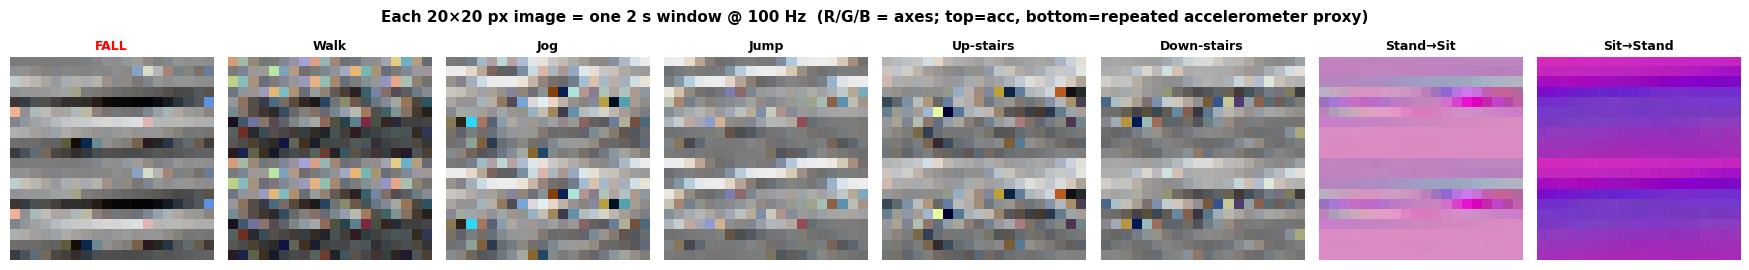

In [4]:
def to_image(row_values):
    """Convert a sample to the 20×20×3 image the CNN sees (0–1 range for display).
    Rows 0–9   = accelerometer.
    Rows 10–19 = rewritten second half for this demo variant.
    """
    row_values = rewrite_second_half(row_values)
    img = row_values.astype(np.float32).reshape(20, 20, 3)
    return img / 255.0   # display-friendly; model further scales to 2x-1

np.random.seed(7)
show_labels_img = [0, 2, 3, 4, 5, 6, 7, 9]
n = len(show_labels_img)

fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))
for ax, label in zip(axes, show_labels_img):
    sample_idx = np.random.randint(len(dfs[label]))
    values = dfs[label].iloc[sample_idx, 1:1201].values.astype(float)
    img = to_image(values)
    ax.imshow(img)
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')

fig.suptitle(f'Each 20×20 px image = one 2 s window @ 100 Hz  (R/G/B = axes; top=acc, bottom={SECOND_HALF_LABEL})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Load the Pre-trained Model

We rebuild the same TF1 graph as in `src/cnn.py` and restore the saved checkpoint.

In [5]:
# Import the model builder from src/
import importlib, cnn as cnn_module
importlib.reload(cnn_module)   # ensure a fresh import

MODEL_PATH = 'model/model.ckpt'

# Build a fresh graph
tf.reset_default_graph()
x_ph  = tf.placeholder(tf.float32, [None, 1200], name='input')
logits, keep_prob_ph = cnn_module.fall_net(x_ph)
probs_op = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
saver.restore(sess, MODEL_PATH)
print('Model restored from', MODEL_PATH)
print('Output shape (logits):', logits.shape)

Model restored from model/model.ckpt
Output shape (logits): (?, 8)


E0000 00:00:1776451072.668639   43848 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776451072.677069   43848 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


### Images of best-detected samples per class: highest softmax probability for the correct class

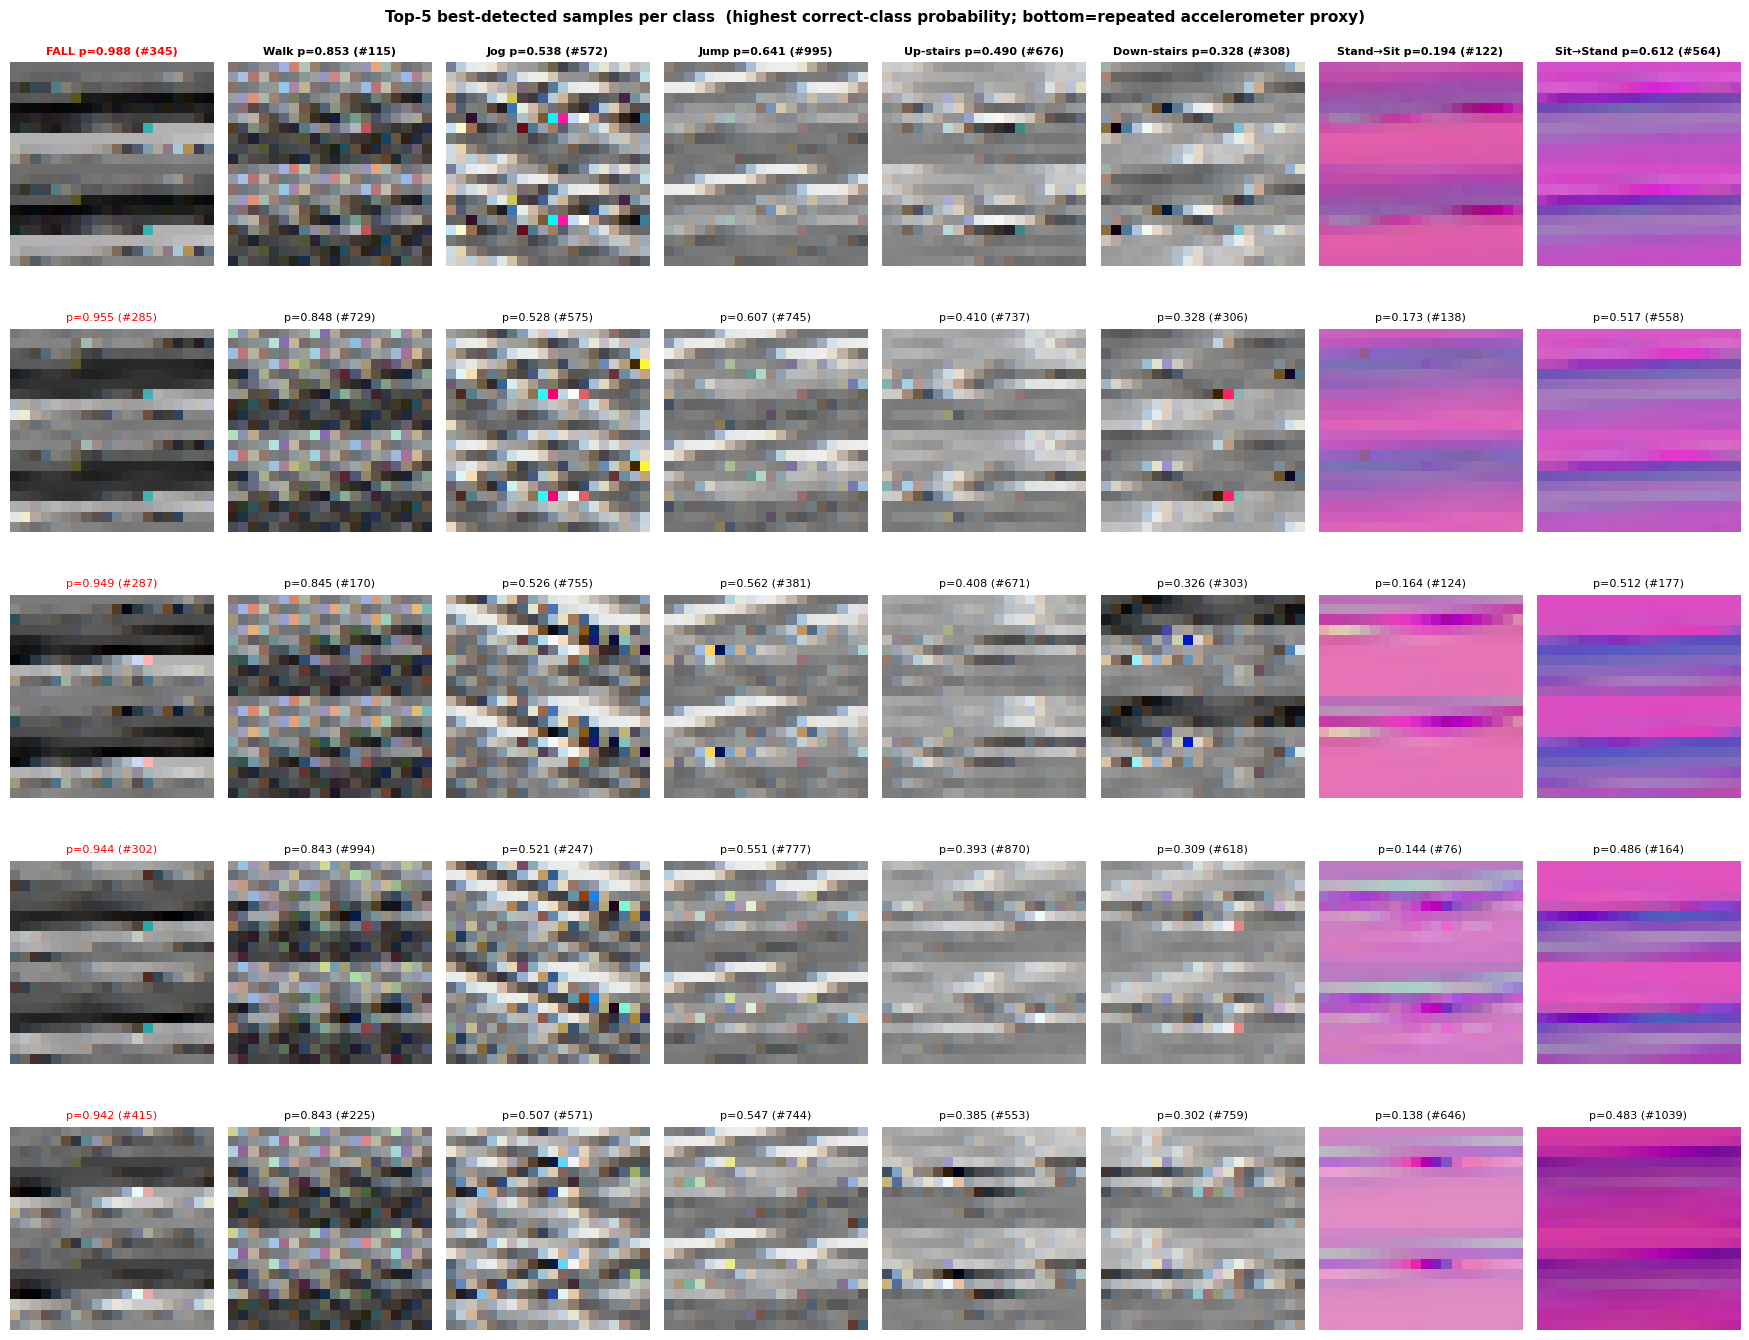

In [6]:
# Top-5 best-detected samples per class
TOP_N = 5
fig, axes = plt.subplots(TOP_N, n, figsize=(2.2 * n, 2.8 * TOP_N))

for col, label in enumerate(show_labels_img):
    df = dfs[label]
    all_X = rewrite_matrix_second_half(df.iloc[:, 1:1201].values.astype(np.float32))

    # Score every sample in this class
    probs = sess.run(probs_op, feed_dict={x_ph: all_X, keep_prob_ph: 1.0})

    # Rank by probability assigned to the correct class (descending)
    correct_class_idx = CLASS_LIST.index(label)
    top_indices = np.argsort(probs[:, correct_class_idx])[::-1][:TOP_N]

    for row, idx in enumerate(top_indices):
        ax = axes[row, col]
        img = to_image(df.iloc[idx, 1:1201].values.astype(float))
        ax.imshow(img)
        prob = probs[idx, correct_class_idx]
        tag = 'FALL' if label == 0 else CLASS_NAMES[label]
        color = 'red' if label == 0 else 'black'
        if row == 0:
            ax.set_title(f'{tag} p={prob:.3f} (#{idx})', fontsize=8,
                         color=color, fontweight='bold')
        else:
            ax.set_title(f'p={prob:.3f} (#{idx})', fontsize=8, color=color)
        ax.axis('off')

fig.suptitle(f'Top-{TOP_N} best-detected samples per class  (highest correct-class probability; bottom={SECOND_HALF_LABEL})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Inference Helper

In [7]:
def predict(samples):
    """
    Run inference on an (N, 1200) array after rewriting the second half.
    Returns:
        pred_labels  : array of integer class labels (values from CLASS_LIST)
        pred_names   : list of human-readable class names
        probabilities: (N, 8) softmax probabilities
    """
    samples = rewrite_matrix_second_half(samples)
    probs = sess.run(probs_op, feed_dict={x_ph: samples, keep_prob_ph: 1.0})
    pred_indices = np.argmax(probs, axis=1)          # index into CLASS_LIST
    pred_labels  = [CLASS_LIST[i] for i in pred_indices]
    pred_names   = [CLASS_NAMES[l] for l in pred_labels]
    return pred_labels, pred_names, probs

print('predict() ready.')


predict() ready.


## 7. Positive Control — Fall Samples

We pick **20 random fall windows** from `0_fall_data.csv` and run them through the model.  
Expected outcome: **all (or nearly all) predicted as Fall**.

In [8]:
np.random.seed(42)
N_SAMPLES = 20

fall_df   = dfs[0]
fall_idx  = np.random.choice(len(fall_df), N_SAMPLES, replace=False)
fall_X    = fall_df.iloc[fall_idx, 1:1201].values.astype(np.float32)

fall_pred_labels, fall_pred_names, fall_probs = predict(fall_X)

print('=== POSITIVE CONTROL (Fall) ===')
print(f'  Samples tested  : {N_SAMPLES}')
correct = sum(1 for l in fall_pred_labels if l == 0)
print(f'  Correctly detected as Fall: {correct}/{N_SAMPLES}  '
      f'(sensitivity = {correct/N_SAMPLES:.1%})')
print()

print(f'  {"#":>3}  {"True":10s}  {"Predicted":12s}  {"Fall prob":>9}  {"Max prob":>9}  OK?')
print('  ' + '-'*58)
for i, (pred_lbl, pred_name, prob_row) in enumerate(
        zip(fall_pred_labels, fall_pred_names, fall_probs)):
    fall_prob = prob_row[CLASS_LIST.index(0)]   # prob assigned to Fall class
    max_prob  = prob_row.max()
    ok = '✓' if pred_lbl == 0 else '✗'
    print(f'  {i+1:>3}  {"Fall":10s}  {pred_name:12s}  {fall_prob:9.4f}  {max_prob:9.4f}  {ok}')

=== POSITIVE CONTROL (Fall) ===
  Samples tested  : 20
  Correctly detected as Fall: 11/20  (sensitivity = 55.0%)

    #  True        Predicted     Fall prob   Max prob  OK?
  ----------------------------------------------------------
    1  Fall        Fall             0.4619     0.4619  ✓
    2  Fall        Fall             0.4954     0.4954  ✓
    3  Fall        Down-stairs      0.0990     0.3048  ✗
    4  Fall        Fall             0.6697     0.6697  ✓
    5  Fall        Down-stairs      0.1011     0.2706  ✗
    6  Fall        Fall             0.7987     0.7987  ✓
    7  Fall        Down-stairs      0.2400     0.2897  ✗
    8  Fall        Down-stairs      0.2589     0.2780  ✗
    9  Fall        Up-stairs        0.0794     0.3301  ✗
   10  Fall        Down-stairs      0.1653     0.2367  ✗
   11  Fall        Down-stairs      0.2381     0.2833  ✗
   12  Fall        Fall             0.6615     0.6615  ✓
   13  Fall        Fall             0.5772     0.5772  ✓
   14  Fall        Fall 

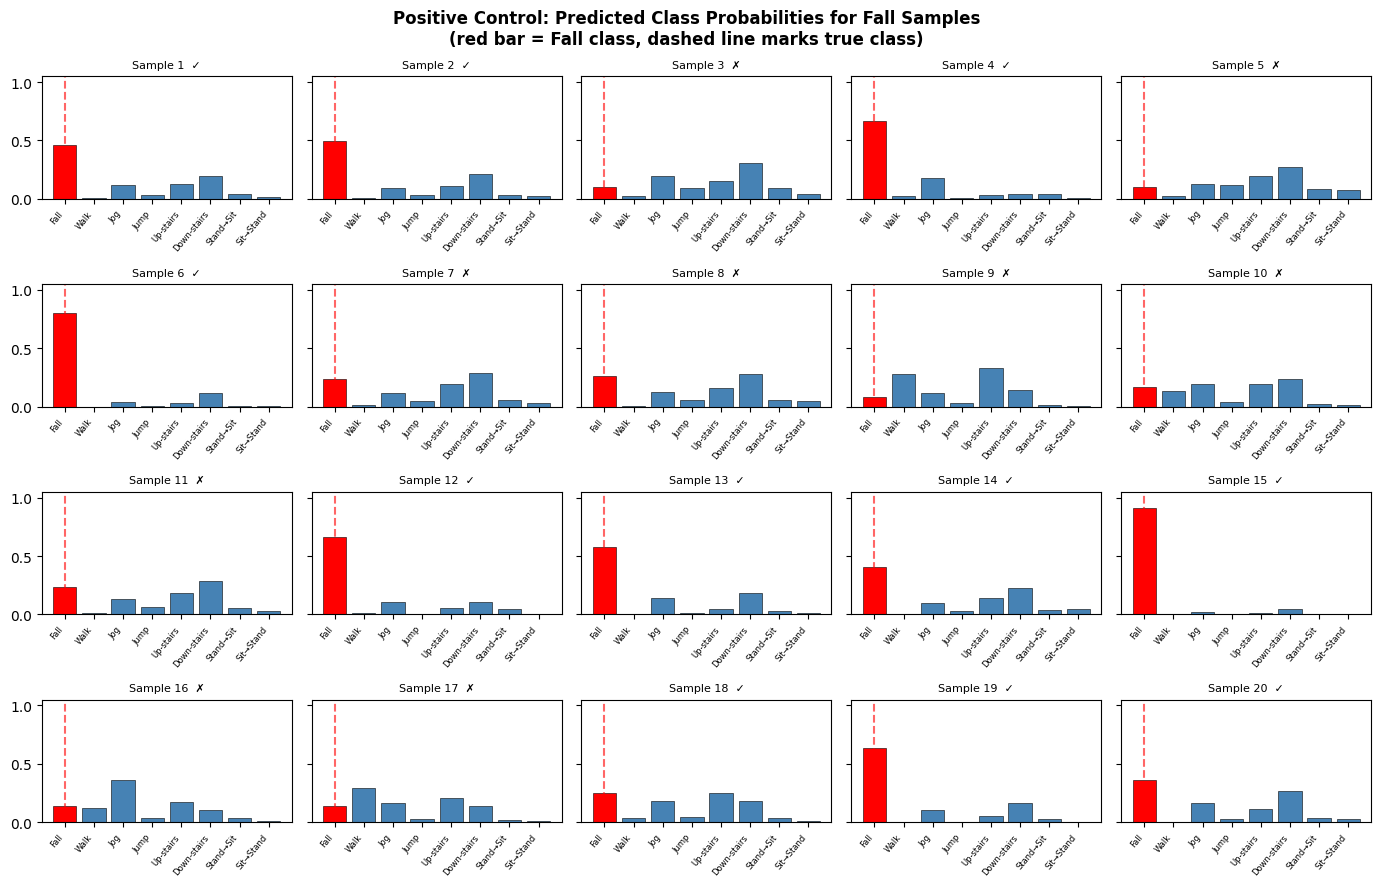

In [9]:
# Probability distributions for the positive-control samples
fig, axes = plt.subplots(4, 5, figsize=(14, 9), sharey=True)
class_name_list = [CLASS_NAMES[l] for l in CLASS_LIST]
colors = ['red' if l == 0 else 'steelblue' for l in CLASS_LIST]

for i, ax in enumerate(axes.flat):
    ax.bar(range(8), fall_probs[i], color=colors, edgecolor='black', linewidth=0.4)
    pred_ok = '✓' if fall_pred_labels[i] == 0 else '✗'
    ax.set_title(f'Sample {i+1}  {pred_ok}', fontsize=8)
    ax.set_xticks(range(8))
    ax.set_xticklabels(class_name_list, rotation=50, ha='right', fontsize=6)
    ax.set_ylim(0, 1.05)
    ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)

fig.suptitle('Positive Control: Predicted Class Probabilities for Fall Samples\n'
             '(red bar = Fall class, dashed line marks true class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Negative Control — Non-Fall Activities

We take **5 samples from each of the 7 non-fall classes** (35 total) and check that the model does **not** classify them as falls (specificity check).

In [10]:
np.random.seed(42)
N_PER_CLASS = 5
non_fall_labels  = []

neg_X_list, neg_true_list = [], []
for label in CLASS_LIST:
    if label == 0:
        continue
    df = dfs[label]
    idx = np.random.choice(len(df), N_PER_CLASS, replace=False)
    neg_X_list.append(df.iloc[idx, 1:1201].values.astype(np.float32))
    neg_true_list.extend([label] * N_PER_CLASS)

neg_X    = np.vstack(neg_X_list)
neg_true = neg_true_list

neg_pred_labels, neg_pred_names, neg_probs = predict(neg_X)

print('=== NEGATIVE CONTROL (Non-Fall Activities) ===')
print(f'  Samples tested  : {len(neg_true)}')
false_alarms = sum(1 for l in neg_pred_labels if l == 0)
print(f'  False alarms (predicted Fall): {false_alarms}/{len(neg_true)}  '
      f'(false-positive rate = {false_alarms/len(neg_true):.1%})')
print()

print(f'  {"#":>3}  {"True class":12s}  {"Predicted":12s}  {"Fall prob":>9}  OK?')
print('  ' + '-'*55)
for i, (true_lbl, pred_lbl, pred_name, prob_row) in enumerate(
        zip(neg_true, neg_pred_labels, neg_pred_names, neg_probs)):
    fall_prob = prob_row[CLASS_LIST.index(0)]
    ok = '✓' if pred_lbl != 0 else '✗ FALSE ALARM'
    true_name = CLASS_NAMES[true_lbl]
    print(f'  {i+1:>3}  {true_name:12s}  {pred_name:12s}  {fall_prob:9.4f}  {ok}')

=== NEGATIVE CONTROL (Non-Fall Activities) ===
  Samples tested  : 35
  False alarms (predicted Fall): 0/35  (false-positive rate = 0.0%)

    #  True class    Predicted     Fall prob  OK?
  -------------------------------------------------------
    1  Walk          Walk             0.1701  ✓
    2  Walk          Walk             0.0316  ✓
    3  Walk          Walk             0.1305  ✓
    4  Walk          Walk             0.0859  ✓
    5  Walk          Walk             0.0159  ✓
    6  Jog           Jog              0.0702  ✓
    7  Jog           Jog              0.0488  ✓
    8  Jog           Up-stairs        0.0545  ✓
    9  Jog           Jog              0.0607  ✓
   10  Jog           Down-stairs      0.0772  ✓
   11  Jump          Jump             0.0838  ✓
   12  Jump          Down-stairs      0.0621  ✓
   13  Jump          Jog              0.0545  ✓
   14  Jump          Jog              0.0431  ✓
   15  Jump          Up-stairs        0.0766  ✓
   16  Up-stairs     Up-stairs   

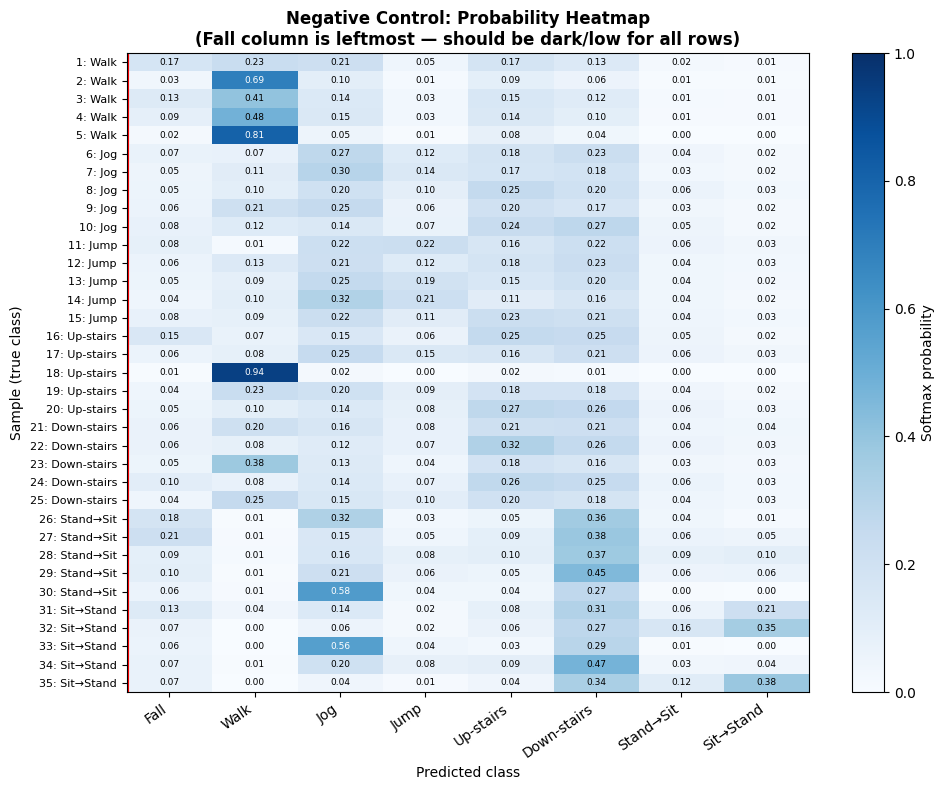

In [11]:
# Heatmap: for each non-fall sample, show all 8 class probabilities
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(neg_probs, aspect='auto', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Softmax probability')

ax.set_xticks(range(8))
ax.set_xticklabels(class_name_list, rotation=35, ha='right')
ax.set_yticks(range(len(neg_true)))
ax.set_yticklabels([f'{i+1}: {CLASS_NAMES[l]}' for i, l in enumerate(neg_true)], fontsize=8)
ax.axvline(x=-0.5, color='red', linewidth=3)   # mark Fall column boundary
ax.set_title('Negative Control: Probability Heatmap\n'
             '(Fall column is leftmost — should be dark/low for all rows)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted class')
ax.set_ylabel('Sample (true class)')

# Overlay text values
for row in range(len(neg_true)):
    for col in range(8):
        val = neg_probs[row, col]
        color = 'white' if val > 0.5 else 'black'
        ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=color)

plt.tight_layout()
plt.show()

## 9. Full Test-Set Evaluation

Run the pre-built `test.csv` through the model and compute per-class accuracy, sensitivity, and specificity — mirroring the paper's reported results.

In [12]:
test_df = pd.read_csv('data/test.csv', index_col=False)

# Filter to rows whose label is in CLASS_LIST
test_df = test_df[test_df['label'].isin(CLASS_LIST)].reset_index(drop=True)

test_X = test_df.iloc[:, 1:1201].values.astype(np.float32)
test_true_labels = test_df['label'].values.astype(int)

test_pred_labels, _, test_probs = predict(test_X)
test_pred_labels = np.array(test_pred_labels)

overall_acc = np.mean(test_pred_labels == test_true_labels)
print(f'Overall accuracy on test.csv: {overall_acc:.4f}  ({overall_acc:.2%})')
print()

print(f'{"Class":>12s}  {"N":>5}  {"Accuracy":>9}  {"Sensitivity":>12}  {"Specificity":>12}')
print('-' * 60)

metrics = []
for label in CLASS_LIST:
    # pass the actual label value — test_pred_labels and test_true_labels use label values, not indices
    acc, sens, spec = cnn_module.evaluate(test_pred_labels, test_true_labels, label)
    n_class = int((test_true_labels == label).sum())
    print(f'{CLASS_NAMES[label]:>12s}  {n_class:>5}  {acc:>9.4f}  {sens:>12.4f}  {spec:>12.4f}')
    metrics.append({'class': CLASS_NAMES[label], 'label': label,
                    'n': n_class, 'accuracy': acc, 'sensitivity': sens, 'specificity': spec})

metrics_df = pd.DataFrame(metrics)

Overall accuracy on test.csv: 0.4092  (40.92%)

       Class      N   Accuracy   Sensitivity   Specificity
------------------------------------------------------------
        Fall     55     0.9241        0.4727        0.9895
        Walk     56     0.8851        0.9464        0.8760
         Jog     47     0.8299        0.8085        0.8325
        Jump     58     0.9080        0.3103        1.0000
   Up-stairs     52     0.8782        0.2500        0.9634
 Down-stairs     55     0.6368        0.4364        0.6658
   Stand→Sit     51     0.8828        0.0000        1.0000
   Sit→Stand     61     0.8736        0.0984        1.0000


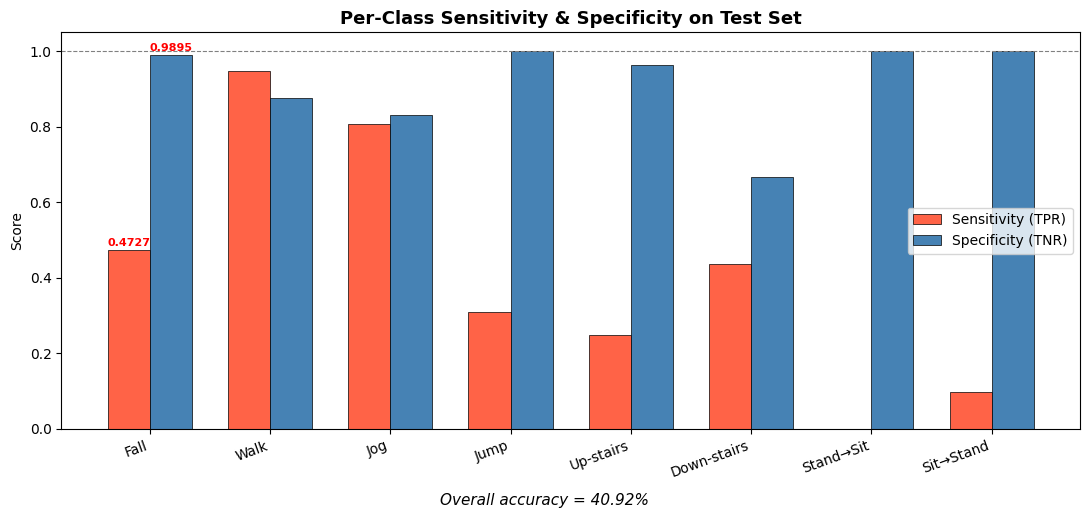

In [13]:
# Bar chart comparison of sensitivity and specificity per class
x = np.arange(len(CLASS_LIST))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, metrics_df['sensitivity'], width,
               label='Sensitivity (TPR)', color='tomato',   edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, metrics_df['specificity'], width,
               label='Specificity (TNR)', color='steelblue', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_df['class'], rotation=20, ha='right')
#ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Per-Class Sensitivity & Specificity on Test Set', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# Annotate Fall bars
for bar in [bars1[0], bars2[0]]:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8, color='red', fontweight='bold')

fig.text(0.5, -0.02, f'Overall accuracy = {overall_acc:.2%}',
         ha='center', fontsize=11, style='italic')
plt.tight_layout()
plt.show()

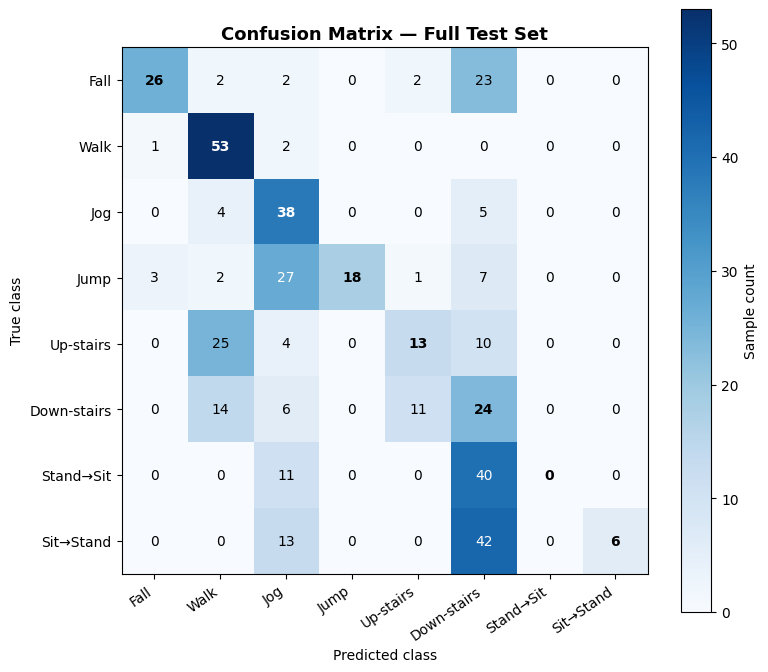

In [14]:
from sklearn.metrics import confusion_matrix

label_names = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(test_true_labels, test_pred_labels, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')

ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix — Full Test Set', fontsize=13, fontweight='bold')

for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val = cm[i, j]
        color = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

## 10. Summary

In [15]:
pos_correct = sum(1 for l in fall_pred_labels if l == 0)
neg_correct = sum(1 for l in neg_pred_labels if l != 0)
n_neg = len(neg_true)

fall_sens = metrics_df.loc[metrics_df['label']==0, 'sensitivity'].values[0]
fall_spec = metrics_df.loc[metrics_df['label']==0, 'specificity'].values[0]
fall_n    = metrics_df.loc[metrics_df['label']==0, 'n'].values[0]

print('=' * 62)
print('  EXPERIMENT SUMMARY')
print('=' * 62)
print()
print(f'  ── Sections 7 & 8: small hand-picked control sets ──────')
print(f'  Positive control  ({N_SAMPLES} random fall samples from dataset):')
print(f'    {pos_correct}/{N_SAMPLES} correct  →  {pos_correct/N_SAMPLES:.1%} sensitivity')
print()
print(f'  Negative control  ({n_neg} random non-fall samples, 5 per class):')
print(f'    {neg_correct}/{n_neg} correct  →  {neg_correct/n_neg:.1%} specificity  '
      f'({n_neg - neg_correct} false alarm(s))')
print()
print(f'  ── Section 9: full test.csv ({len(test_true_labels)} samples) ──────────────')
print(f'  Overall accuracy : {overall_acc:.2%}')
print(f'  Fall class       : {fall_n} samples  |  '
      f'sensitivity {fall_sens:.4f}  |  specificity {fall_spec:.4f}')
print()
print('  Note: the "20" and "55 falls" are different experiments.')
print('  Section 7 draws 20 samples directly from the raw dataset.')
print('  Section 9 uses test.csv (the held-out split), which')
print('  happened to contain 55 fall windows.')
print('=' * 62)

sess.close()
print('Session closed.')

  EXPERIMENT SUMMARY

  ── Sections 7 & 8: small hand-picked control sets ──────
  Positive control  (20 random fall samples from dataset):
    11/20 correct  →  55.0% sensitivity

  Negative control  (35 random non-fall samples, 5 per class):
    35/35 correct  →  100.0% specificity  (0 false alarm(s))

  ── Section 9: full test.csv (435 samples) ──────────────
  Overall accuracy : 40.92%
  Fall class       : 55 samples  |  sensitivity 0.4727  |  specificity 0.9895

  Note: the "20" and "55 falls" are different experiments.
  Section 7 draws 20 samples directly from the raw dataset.
  Section 9 uses test.csv (the held-out split), which
  happened to contain 55 fall windows.
Session closed.
